In [1]:
"""
- ID3 (Iterative Dichotomiser 3) was developed in 1986 by Ross Quinlan. The algorithm creates a multiway tree, finding 
      for each node (i.e. in a greedy manner) the categorical feature that will yield the largest information gain for 
      categorical targets. Trees are grown to their maximum size and then a pruning step is usually applied to improve 
      the ability of the tree to generalise to unseen data.
      
- C4.5 is the successor to ID3 and removed the restriction that features must be categorical by dynamically defining a 
      discrete attribute (based on numerical variables) that partitions the continuous attribute value into a discrete 
      set of intervals. C4.5 converts the trained trees (i.e. the output of the ID3 algorithm) into sets of if-then rules.
      These accuracy of each rule is then evaluated to determine the order in which they should be applied. Pruning is 
      done by removing a rule’s precondition if the accuracy of the rule improves without it.

- C5.0 is Quinlan’s latest version release under a proprietary license. It uses less memory and builds smaller rulesets 
      than C4.5 while being more accurate.

- CART (Classification and Regression Trees) is very similar to C4.5, but it differs in that it supports numerical 
      target variables (regression) and does not compute rule sets. CART constructs binary trees using the feature and 
      threshold that yield the largest information gain at each node.

*** scikit-learn uses an optimised version of the CART algorithm ***
Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
"""

%matplotlib inline
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("error", category=UndefinedMetricWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import fbeta_score
from sklearn.metrics import auc
from sklearn.model_selection import StratifiedKFold
from sklearn import metrics
from sklearn.tree import export_graphviz
from sklearn.externals.six import StringIO  
from IPython.display import Image  
import pydotplus

def PlotTree(clf, features, name="Tree.png"):
    dot_data=StringIO()
    export_graphviz(clf, out_file=dot_data, filled=True, rounded=True, special_characters=True,
                    feature_names=features,class_names=['0','1'])
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
    graph.write_png(name)
    return Image(graph.create_png())

def GetMetrics(y_test, y_pred):
    print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
    display("confusion_matrix", pd.DataFrame(metrics.confusion_matrix(y_test, y_pred)))
    report = metrics.classification_report(y_test, y_pred, output_dict=True)
    display("metrics", pd.DataFrame(report).transpose())


In [2]:
## Load Dataset ....

Class=["refatoracao"]
features = [ "LOC", "NPM", "WMC", "NOC", "DIT", "CAM", 
             "CBO", "RFC", "LCOM", "CA", "CE", "LCOM3",
             "DAM", "MOA", "MFA", "IC", "CBM", "AMC", ]
df = pd.read_csv('dataset_refat_final.csv',delimiter=";", decimal=".") #, header=True) #,names=features)
x = df[features]
y = df[Class]
print("Data Size: ",df.shape)
df[features+Class].head()

Data Size:  (2030, 25)


,LOC,NPM,WMC,NOC,DIT,CAM,CBO,RFC,LCOM,CA,CE,LCOM3,DAM,MOA,MFA,IC,CBM,AMC,refatoracao
0,1656.0,88.0,100.0,0.0,0.0,0.2148,6.0,140.0,4940.0,0.0,6.0,0.2222,0.8333,0.0,0.0,0.0,0.0,15.5,1.0
1,253.0,11.0,14.0,4.0,1.0,0.1688,7.0,46.0,79.0,4.0,3.0,0.8718,0.3333,0.0,0.0,0.0,0.0,168571.0,1.0
2,1421.0,88.0,96.0,0.0,0.0,0.2211,6.0,130.0,4554.0,0.0,6.0,0.5263,0.5000,0.0,0.0,0.0,0.0,137813.0,1.0
3,517.0,24.0,30.0,0.0,0.0,0.2867,5.0,57.0,341.0,0.0,5.0,0.9151,0.0000,0.0,0.0,0.0,0.0,15.8,1.0
4,783.0,17.0,22.0,0.0,0.0,0.2273,8.0,65.0,105.0,0.0,8.0,0.9568,0.1875,1.0,0.0,0.0,0.0,331364.0,1.0


Accuracy: 0.8407224958949097


'confusion_matrix'

,0,1
0,271,37
1,60,241


'metrics'

,f1-score,precision,recall,support
0.0,0.848200,0.818731,0.879870,308.0
1.0,0.832470,0.866906,0.800664,301.0
micro avg,0.840722,0.840722,0.840722,609.0
macro avg,0.840335,0.842819,0.840267,609.0
weighted avg,0.840425,0.842542,0.840722,609.0


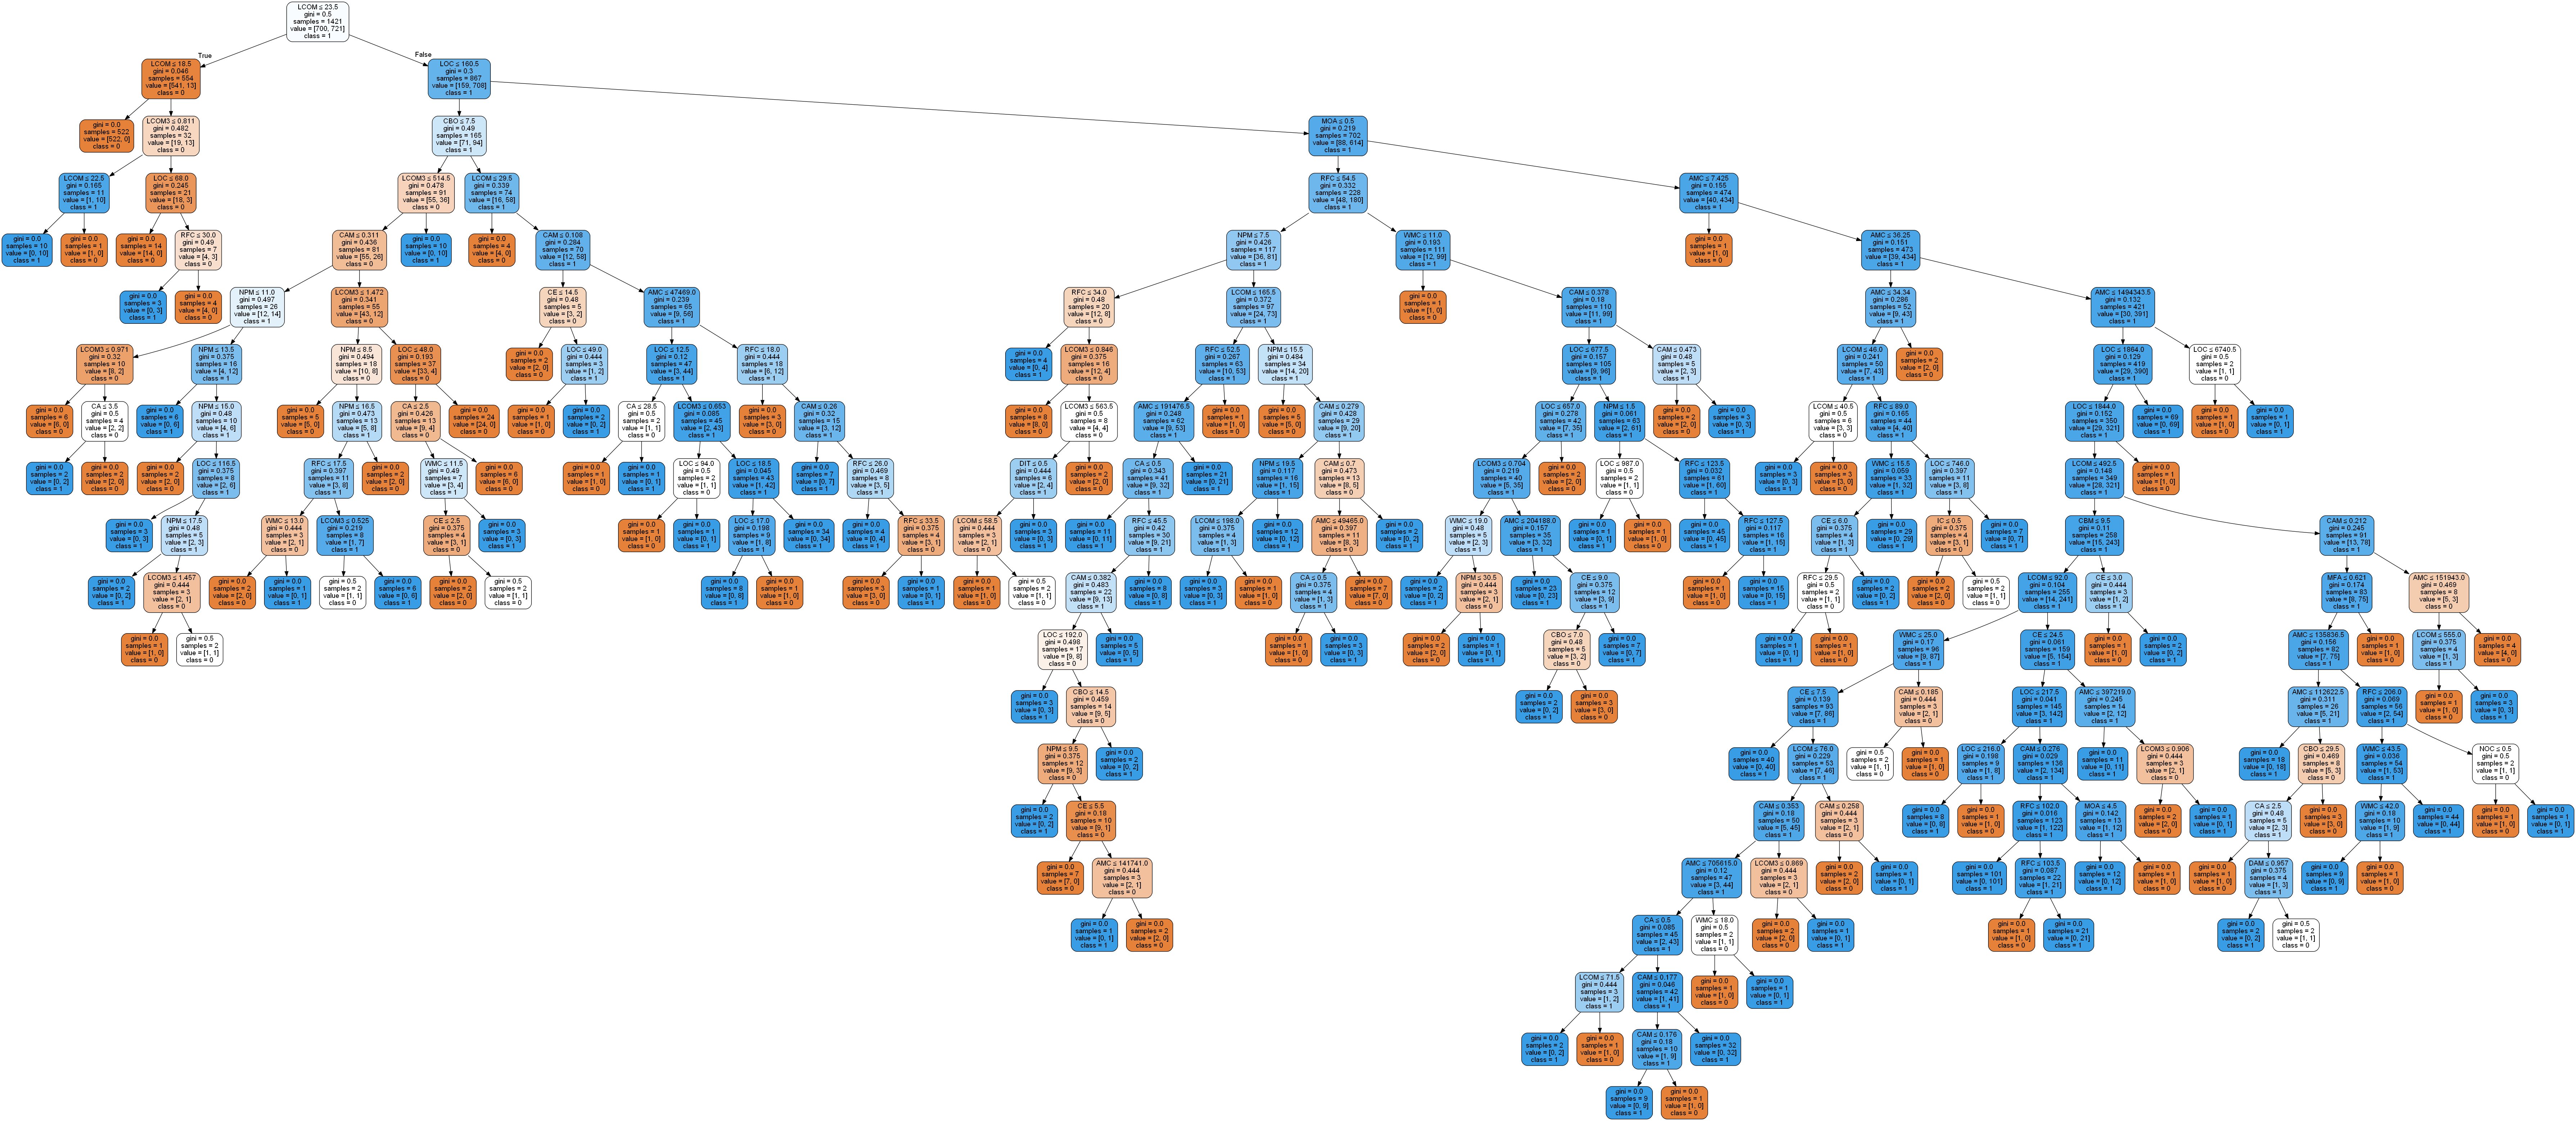

In [3]:
# Default params for DecisionTreeClassifier and split randomly the dataset in training and test (70% training, 30% test)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1) 
clf = DecisionTreeClassifier(random_state=0)
clf = clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

GetMetrics(y_test, y_pred)
PlotTree(clf, features, "Tree.png")

Decision tree tuning
Steps:
 [('dec_tree', DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best'))]
Best Parameters:
	 Params: {'dec_tree__criterion': 'entropy', 'dec_tree__max_depth': 10, 'dec_tree__max_features': 2, 'dec_tree__min_samples_leaf': 16, 'dec_tree__min_samples_split': 2}
	 Score: 0.9345955731299935

** metrics for ALL data set
Accuracy: 0.9019704433497537


'confusion_matrix'

,0,1
0,852,156
1,43,979


'metrics'

,f1-score,precision,recall,support
0.0,0.895428,0.951955,0.845238,1008.0
1.0,0.907742,0.862555,0.957926,1022.0
micro avg,0.901970,0.901970,0.901970,2030.0
macro avg,0.901585,0.907255,0.901582,2030.0
weighted avg,0.901628,0.906947,0.901970,2030.0


** metrics for the test data set (previous model - 70% training and 30% test)
Accuracy: 0.9113300492610837


'confusion_matrix'

,0,1
0,267,41
1,13,288


'metrics'

,f1-score,precision,recall,support
0.0,0.908163,0.953571,0.866883,308.0
1.0,0.914286,0.875380,0.956811,301.0
micro avg,0.911330,0.911330,0.911330,609.0
macro avg,0.911224,0.914476,0.911847,609.0
weighted avg,0.911189,0.914925,0.911330,609.0


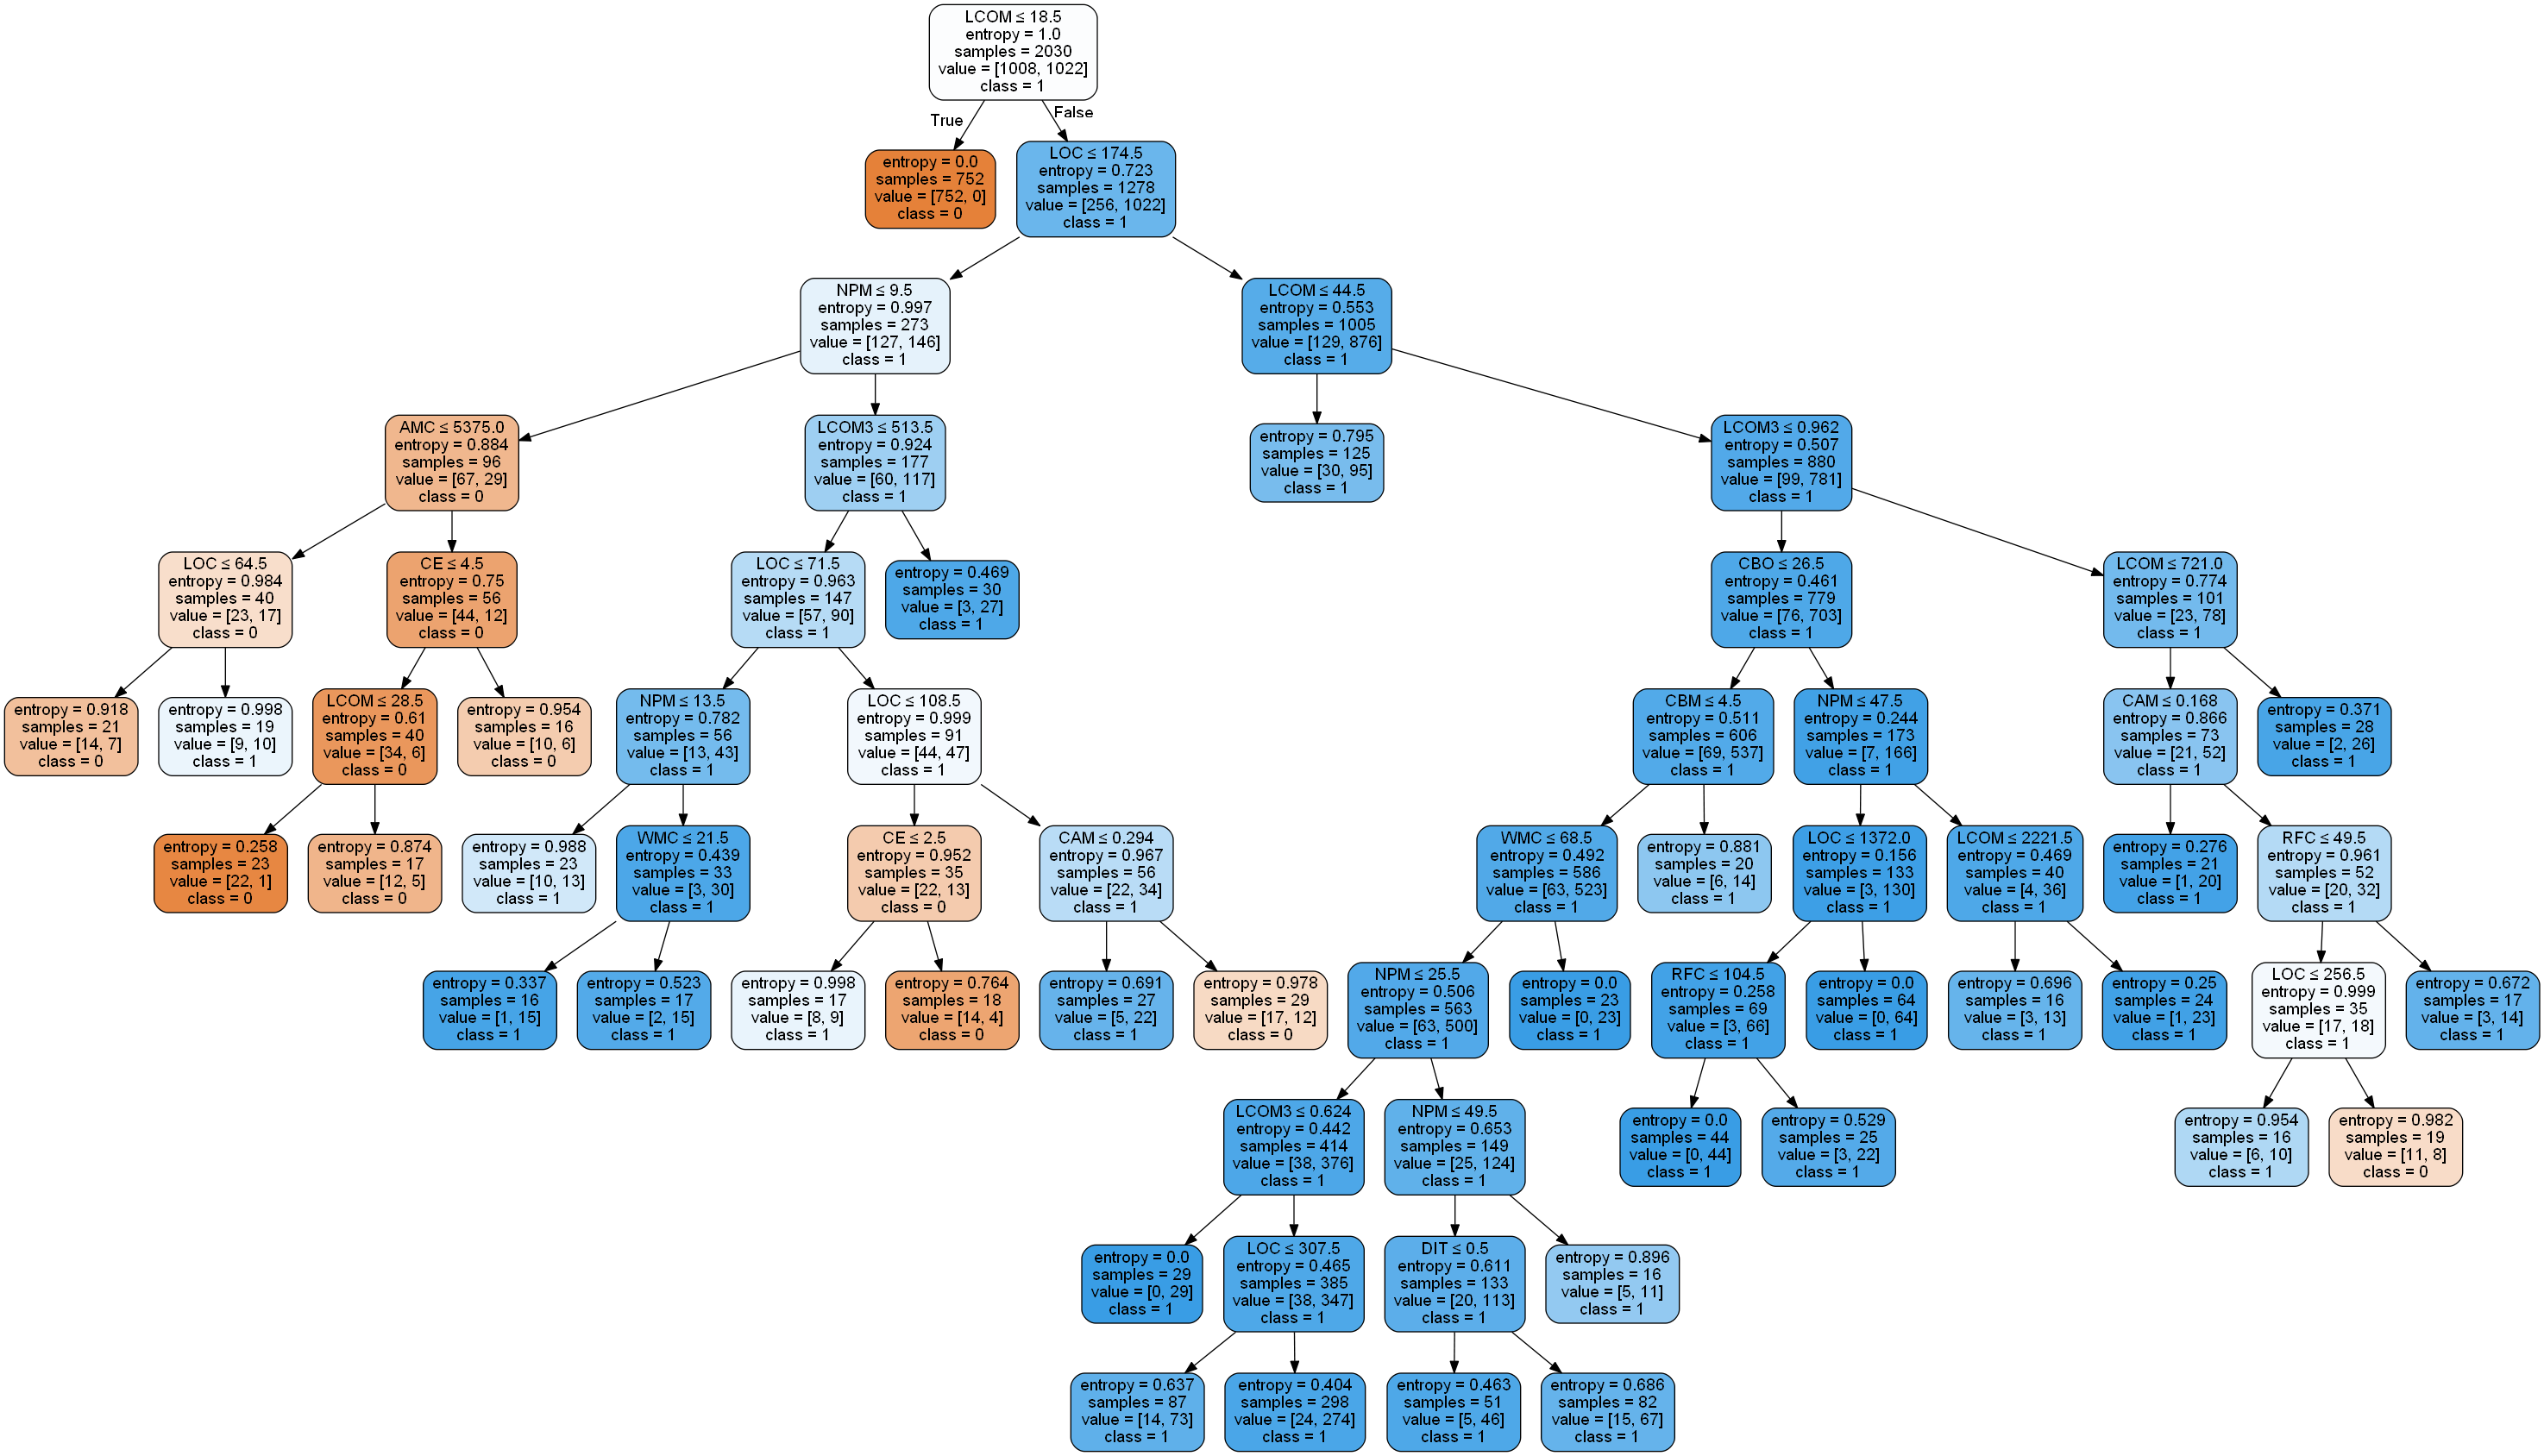

In [4]:
## Find the best params for DecisionTreeClassifier and we use KFold

dec_tree = DecisionTreeClassifier(random_state=0) # random_state - deterministic behaviour during fitting random_state has to be fixed to an integer
pipe = Pipeline(steps=[ ('dec_tree', dec_tree)])
parameters = dict(dec_tree__criterion=['gini', 'entropy'],
                  dec_tree__min_samples_split=[2, 4, 8, 16, 32],
                  dec_tree__min_samples_leaf=[2, 4, 8, 16, 32],
                  dec_tree__max_depth=[2, 4, 6, 8, 10, 12, 14, 16, 18],
                  dec_tree__max_features=[2, 4, 6, 8, 10, 12, 14, 16, 18],
                 )
scores = {'accuracy' :make_scorer(accuracy_score),
          'recall'   :make_scorer(recall_score),
          'precision':make_scorer(precision_score),
          'f1'       :make_scorer(fbeta_score, beta = 1),
          'auc'      :make_scorer(auc),
         }
KF = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
clf_GS = GridSearchCV(pipe, param_grid = parameters, n_jobs=-1, cv=KF,
                      #scoring = scores,   refit = 'auc', 
                      scoring = 'roc_auc',
                     )
clf_GS_fit=clf_GS.fit(x, y)

print("Decision tree tuning")
print("Steps:\n",pipe.steps)
print("Best Parameters:\n\t Params: {}\n\t Score: {}\n".format(clf_GS.best_params_,clf_GS.best_score_))

print("** metrics for ALL data set")
y_pred = clf_GS_fit.predict(x)
GetMetrics(y, y_pred)

print("** metrics for the test data set (previous model - 70% training and 30% test)")
y_pred = clf_GS_fit.predict(X_test)
GetMetrics(y_test, y_pred)

PlotTree(clf_GS.best_estimator_.named_steps["dec_tree"], features, "Tree_GS.png")


In [14]:
TrainParmResults=pd.DataFrame(clf_GS.cv_results_)
pd.options.display.max_columns = None
TrainParmResults.head(6) # -1 Show all 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_dec_tree__criterion,param_dec_tree__max_depth,param_dec_tree__max_features,param_dec_tree__min_samples_leaf,param_dec_tree__min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,split5_train_score,split6_train_score,split7_train_score,split8_train_score,split9_train_score,mean_train_score,std_train_score
0,0.006656,0.004042,0.003221,0.003727,gini,2,2,2,2,"{'dec_tree__criterion': 'gini', 'dec_tree__max...",0.91762,0.914159,0.891235,0.911619,0.905601,0.890555,0.911037,0.909338,0.881814,0.886275,0.901957,0.012382,3605,0.905668,0.906397,0.903999,0.906679,0.902225,0.908628,0.90673,0.907004,0.910379,0.904256,0.906197,0.002219
1,0.010712,0.004412,0.003035,0.003156,gini,2,2,2,4,"{'dec_tree__criterion': 'gini', 'dec_tree__max...",0.91762,0.914159,0.891235,0.911619,0.905601,0.890555,0.911037,0.909338,0.881814,0.886275,0.901957,0.012382,3605,0.905668,0.906397,0.903999,0.906679,0.902225,0.908628,0.90673,0.907004,0.910379,0.904256,0.906197,0.002219
2,0.005255,0.004534,0.007057,0.008887,gini,2,2,2,8,"{'dec_tree__criterion': 'gini', 'dec_tree__max...",0.91762,0.914159,0.891235,0.911619,0.905601,0.890555,0.911037,0.909338,0.881814,0.886275,0.901957,0.012382,3605,0.905668,0.906397,0.903999,0.906679,0.902225,0.908628,0.90673,0.907004,0.910379,0.904256,0.906197,0.002219
3,0.003634,0.003903,0.003827,0.004361,gini,2,2,2,16,"{'dec_tree__criterion': 'gini', 'dec_tree__max...",0.91762,0.914159,0.891235,0.911619,0.905601,0.890555,0.911037,0.909338,0.881814,0.886275,0.901957,0.012382,3605,0.905668,0.906397,0.903999,0.906679,0.902225,0.908628,0.90673,0.907004,0.910379,0.904256,0.906197,0.002219
4,0.004850,0.004157,0.004252,0.004095,gini,2,2,2,32,"{'dec_tree__criterion': 'gini', 'dec_tree__max...",0.91762,0.914159,0.891235,0.911619,0.905601,0.890555,0.911037,0.909338,0.881814,0.886275,0.901957,0.012382,3605,0.905668,0.906397,0.903999,0.906679,0.902225,0.908628,0.90673,0.907004,0.910379,0.904256,0.906197,0.002219
5,0.007889,0.002872,0.002433,0.002973,gini,2,2,4,2,"{'dec_tree__criterion': 'gini', 'dec_tree__max...",0.91762,0.914159,0.891235,0.911619,0.905601,0.890555,0.911037,0.909338,0.881814,0.886275,0.901957,0.012382,3605,0.905668,0.906397,0.903999,0.906679,0.902225,0.908628,0.90673,0.907004,0.910379,0.904256,0.906197,0.002219
